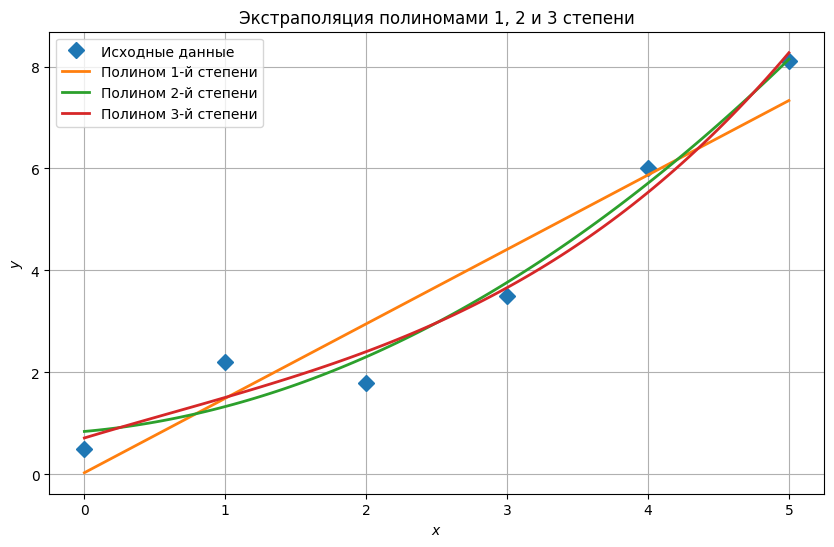

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0])
y = np.array([0.5, 2.2, 1.8, 3.5, 6.0, 8.1])

A1 = np.vstack([x, np.ones(len(x))]).T
m1, c1 = np.linalg.lstsq(A1, y, rcond=None)[0]

A2 = np.vstack([x**2, x, np.ones(len(x))]).T
s2 = np.linalg.lstsq(A2, y, rcond=None)[0]

A3 = np.vstack([x**3, x**2, x, np.ones(len(x))]).T
s3 = np.linalg.lstsq(A3, y, rcond=None)[0]

x_prec = np.linspace(min(x), max(x), 100)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'D', label='Исходные данные', markersize=8)
plt.plot(x_prec, m1 * x_prec + c1, label='Полином 1-й степени', linewidth=2)
plt.plot(x_prec, s2[0] * x_prec**2 + s2[1] * x_prec + s2[2], label='Полином 2-й степени', linewidth=2)
plt.plot(x_prec, s3[0] * x_prec**3 + s3[1] * x_prec**2 + s3[2] * x_prec + s3[3], label='Полином 3-й степени', linewidth=2)

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.grid(True)
plt.title('Экстраполяция полиномами 1, 2 и 3 степени')
plt.show()

In [3]:
from scipy.optimize import curve_fit

xdata = np.linspace(0.5, 5, 40)
ydata = 1.5 + 2.5 * np.log(xdata) + 0.1 * np.random.randn(len(xdata))

def f(x, b0, b1):
    return b0 + b1 * np.log(x)


beta_opt, beta_cov = curve_fit(f, xdata, ydata)
print("Оптимальные коэффициенты (b0, b1):", beta_opt)

lin_dev = np.sum(np.diag(beta_cov))
residuals = ydata - f(xdata, *beta_opt)
fres = np.sum(residuals**2)
print('Линейное отклонение:', lin_dev)
print('Квадратичное отклонение:', fres)

Оптимальные коэффициенты (b0, b1): [1.52495425 2.49373184]
Линейное отклонение: 0.0013758409921683264
Квадратичное отклонение: 0.3729159762870734


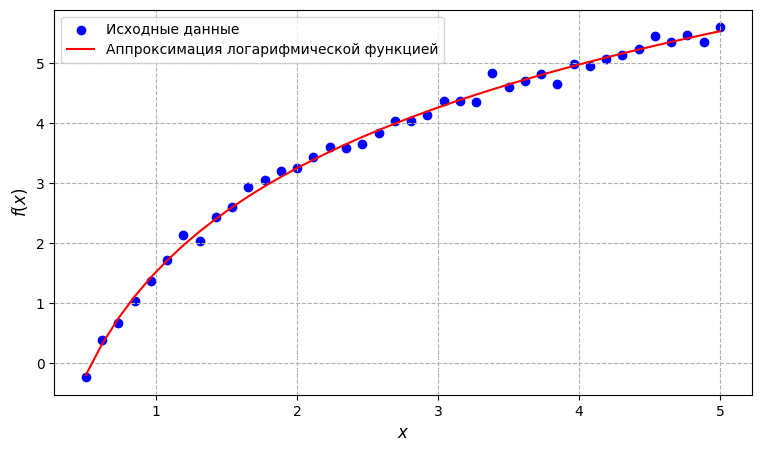

In [8]:
plt.figure(figsize=(9, 5))
plt.scatter(xdata, ydata, label='Исходные данные', color='blue')
plt.plot(xdata, f(xdata, *beta_opt), 'r-', label='Аппроксимация логарифмической функцией')

plt.xlabel('$x$', fontsize=12)
plt.ylabel('$f(x)$', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

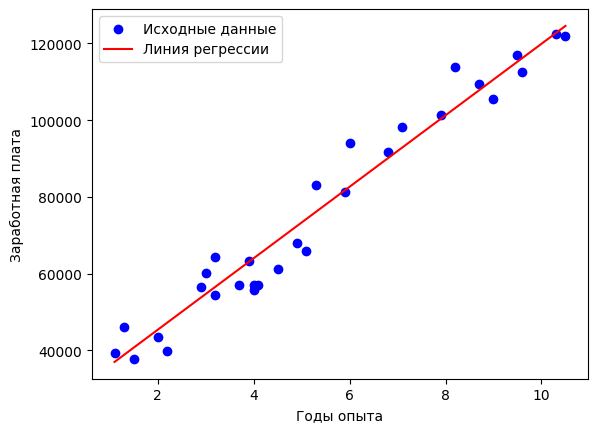

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

url = 'https://raw.githubusercontent.com/AnnaShestova/salary-years-simple-linear-regression/master/Salary_Data.csv'
dataset = pd.read_csv(url)

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

print('Сдвиг:', regressor.intercept_)
print('Наклон:', regressor.coef_)

y_pred = regressor.predict(X_test)
df_preds = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(df_preds)

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

plt.scatter(X, y, color='blue', label='Исходные данные')
plt.plot(X, regressor.predict(X), color='red', label='Линия регрессии')
plt.xlabel('Годы опыта')
plt.ylabel('Заработная плата')
plt.legend()
plt.show()

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

url = 'https://raw.githubusercontent.com/likarajo/petrol_consumption/master/data/petrol_consumption.csv'
dataset = pd.read_csv(url)

X = dataset.iloc[:, 1:5].values
y = dataset.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

regressor = LinearRegression()
regressor.fit(X_train, y_train)

print('Коэффициенты:', regressor.coef_)
print('Свободный член:', regressor.intercept_)

coeff_df = pd.DataFrame(regressor.coef_, dataset.columns[1:5], columns=['Coefficient'])
print(coeff_df)

y_pred = regressor.predict(X_test)
df_preds = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(df_preds.head())

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Коэффициенты: [-1.06929951e-04 -1.51880698e-04  2.11035388e+00 -5.05813229e-03]
Свободный член: 10.71406832448172
                              Coefficient
Average_income                  -0.000107
Paved_Highways                  -0.000152
Population_Driver_licence(%)     2.110354
Petrol_Consumption              -0.005058
   Actual  Predicted
0     9.0   7.962130
1     8.0   9.252421
2     8.0   7.763302
3     7.0   7.481077
4     8.0   7.696914
MAE: 0.5689458900566693
MSE: 0.4587686097483707
RMSE: 0.6773245970348122


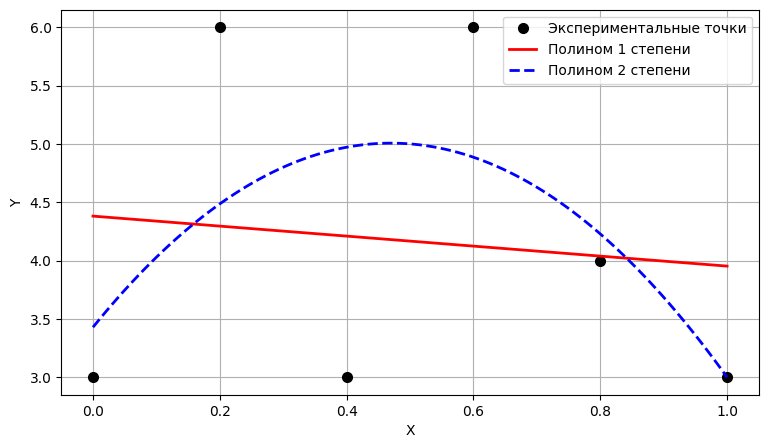

In [14]:
x = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
y = np.array([3.0, 6.0, 3.0, 6.0, 4.0, 3.0])

A1 = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A1, y, rcond=None)[0]
y_pred_1 = m * x + c

A2 = np.vstack([x**2, x, np.ones(len(x))]).T
a, b, d = np.linalg.lstsq(A2, y, rcond=None)[0]
y_pred_2 = a * (x**2) + b * x + d

results_df = pd.DataFrame({
    'x': x,
    'y_fact': y,
    'y_pred_1 (deg 1)': np.round(y_pred_1, 4),
    'y_pred_2 (deg 2)': np.round(y_pred_2, 4)
})
print('значения:')
print(results_df)

print(f'полином 1 степени: y = {m}*x + {c}')
print(f'полином 2 степени: y = {a}*x^2 + {b}*x + {d}')

x_prec = np.linspace(min(x), max(x), 100)
plt.figure(figsize=(9, 5))
plt.plot(x, y, 'ko', label='Экспериментальные точки', markersize=7)
plt.plot(x_prec, m * x_prec + c, 'r-', label='Полином 1 степени', linewidth=2)
plt.plot(x_prec, a * (x_prec**2) + b * x_prec + d, 'b--', label='Полином 2 степени', linewidth=2)

plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()